Passo a passo do projeto

In [ ]:
#1 - Análise de dados (Entender o dataset, verificar nulos e estatisticas)
#2 - Feature Engineering (Tratar e preparar os dados para o modelo)
#3 - Modelo de ML (Treinar e avaliar)
#4 - Salvar o modelo
#5 - App Streamlit


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Obesity.csv')

In [4]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
#Antes de analisar, precisamos saber o tamanho do problema: quantas linhas (pacientes) e colunas (atributos) temos, e se o Pandas entendeu os tipos de dados corretamente.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   str    
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   str    
 5   FAVC            2111 non-null   str    
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   str    
 9   SMOKE           2111 non-null   str    
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   str    
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   str    
 15  MTRANS          2111 non-null   str    
 16  Obesity         2111 non-null   str    
dtypes: float64(8), str(9)
memory usage: 414.2 KB

In [6]:
# .shape retorna (número de linhas, número de colunas)
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

Linhas: 2111 | Colunas: 17


In [7]:
df.dtypes

Gender                str
Age               float64
Height            float64
Weight            float64
family_history        str
FAVC                  str
FCVC              float64
NCP               float64
CAEC                  str
SMOKE                 str
CH2O              float64
SCC                   str
FAF               float64
TUE               float64
CALC                  str
MTRANS                str
Obesity               str
dtype: object

In [8]:
#Verificar nulos
# Calculando a quantidade de nulos por coluna
valores_nulos = df.isnull().sum()

In [9]:
# Resumo estatístico das variáveis numéricas, transposto para melhor visualização
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [10]:
# A coluna 'Obesity' é o que queremos prever (variável alvo).
# .value_counts() conta quantas vezes cada classe aparece.
# normalize=True transforma em percentual.
contagem = df['Obesity'].value_counts()
percentual = df['Obesity'].value_counts(normalize=True).mul(100).round(1)
resumo_alvo = pd.DataFrame({'Quantidade': contagem, 'Percentual (%)': percentual})

In [11]:
print(resumo_alvo)

                     Quantidade  Percentual (%)
Obesity                                        
Obesity_Type_I              351            16.6
Obesity_Type_III            324            15.3
Obesity_Type_II             297            14.1
Overweight_Level_I          290            13.7
Overweight_Level_II         290            13.7
Normal_Weight               287            13.6
Insufficient_Weight         272            12.9


In [12]:
# Colunas categóricas = colunas de texto (sim/não, masculino/feminino...)
# Vamos ver quantas vezes cada valor aparece em cada coluna.
cat_cols = ['Gender', 'family_history', 'FAVC', 'CAEC',
            'SMOKE', 'SCC', 'CALC', 'MTRANS']

In [13]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())


Gender:
Gender
Male      1068
Female    1043

family_history:
family_history
yes    1726
no      385

FAVC:
FAVC
yes    1866
no      245

CAEC:
CAEC
Sometimes     1765
Frequently     242
Always          53
no              51

SMOKE:
SMOKE
no     2067
yes      44

SCC:
SCC
no     2015
yes      96

CALC:
CALC
Sometimes     1401
no             639
Frequently      70
Always           1

MTRANS:
MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7


In [14]:
# Estilo visual dos gráficos
sns.set_theme(style="whitegrid", palette="muted")

In [15]:
# Ordem das classes de obesidade (do mais leve ao mais grave)
ordem_obesidade = [
    'Insufficient_Weight', 'Normal_Weight',
    'Overweight_Level_I', 'Overweight_Level_II',
    'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'
]

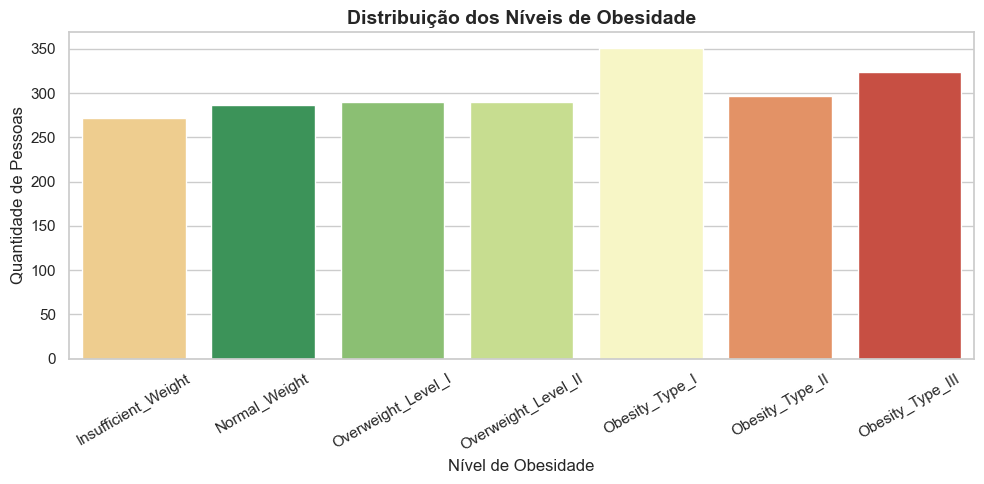

In [16]:
# ── GRÁFICO 1: Distribuição da variável alvo ─────────────────
# Um gráfico de barras mostrando quantas pessoas há em cada
# nível de obesidade. Importante para ver se as classes estão
# balanceadas (quantidade parecida entre si).
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x='Obesity', order=ordem_obesidade,
              hue='Obesity', palette='RdYlGn_r', legend=False, ax=ax)
ax.set_title('Distribuição dos Níveis de Obesidade', fontsize=14, fontweight='bold')
ax.set_xlabel('Nível de Obesidade')
ax.set_ylabel('Quantidade de Pessoas')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

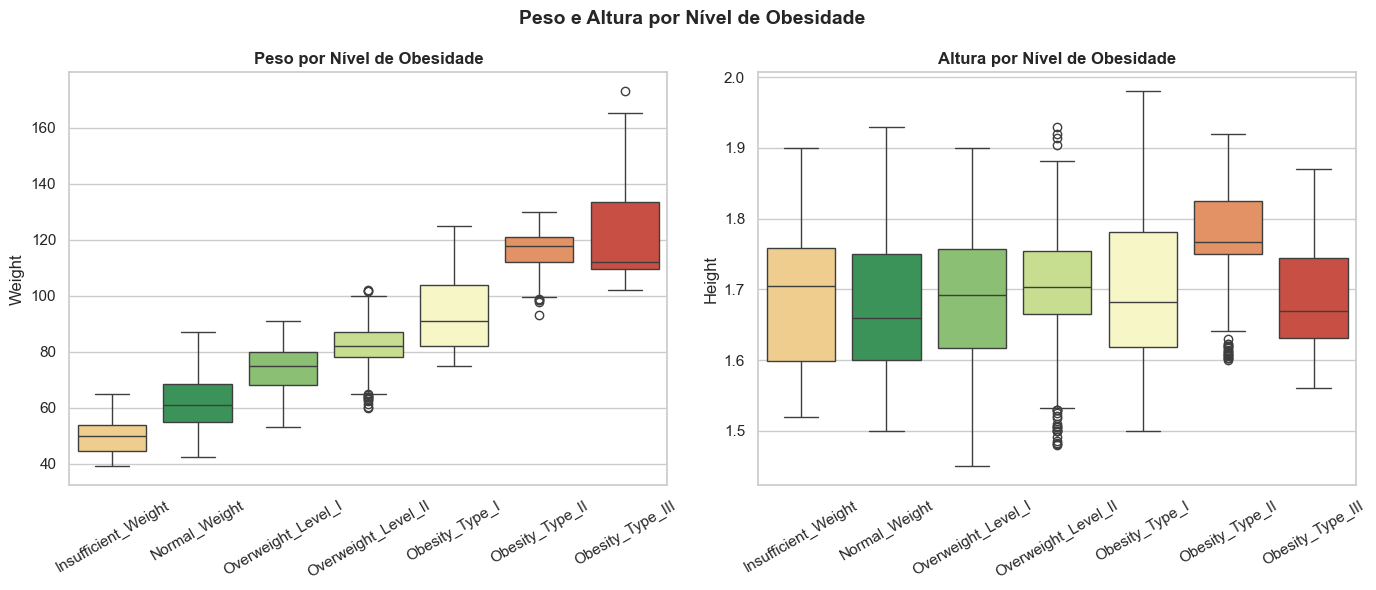

In [17]:
# ── GRÁFICO 2: Peso e Altura por nível de obesidade ──────────
# Boxplot: mostra a distribuição de um valor numérico por grupo.
# A "caixa" representa 50% dos dados; a linha do meio é a mediana.
# Pontos fora dos "bigodes" são outliers (valores atípicos).
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df, x='Obesity', y='Weight', order=ordem_obesidade,
            hue='Obesity', palette='RdYlGn_r', legend=False, ax=axes[0])
axes[0].set_title('Peso por Nível de Obesidade', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='Obesity', y='Height', order=ordem_obesidade,
            hue='Obesity', palette='RdYlGn_r', legend=False, ax=axes[1])
axes[1].set_title('Altura por Nível de Obesidade', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Peso e Altura por Nível de Obesidade', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

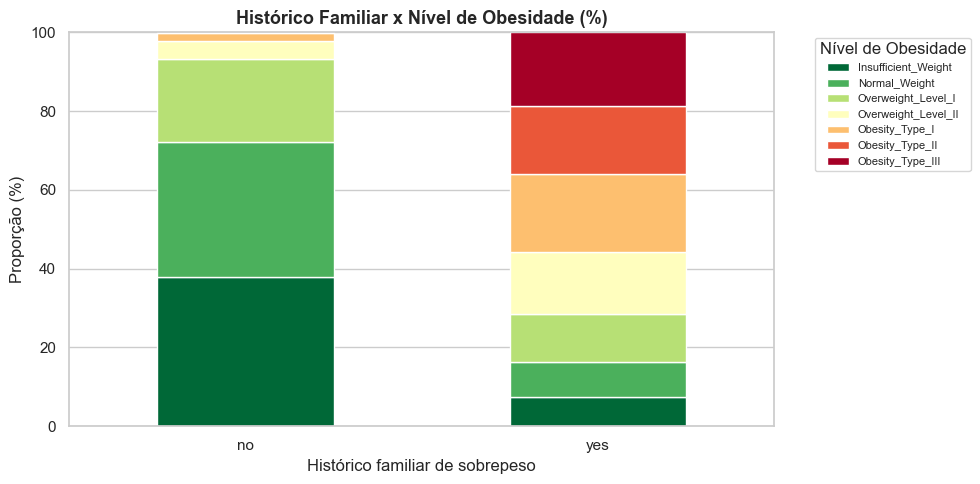

In [18]:
# ── GRÁFICO 3: Histórico familiar x Obesidade ────────────────
# Mostra se ter família com sobrepeso influencia o nível de obesidade.
# Usamos stacked bar (barras empilhadas) para comparar proporções.
tabela = pd.crosstab(df['family_history'], df['Obesity'])[ordem_obesidade]
tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
tabela_pct.plot(kind='bar', stacked=True, colormap='RdYlGn_r', ax=ax)
ax.set_title('Histórico Familiar x Nível de Obesidade (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Histórico familiar de sobrepeso')
ax.set_ylabel('Proporção (%)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Nível de Obesidade', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

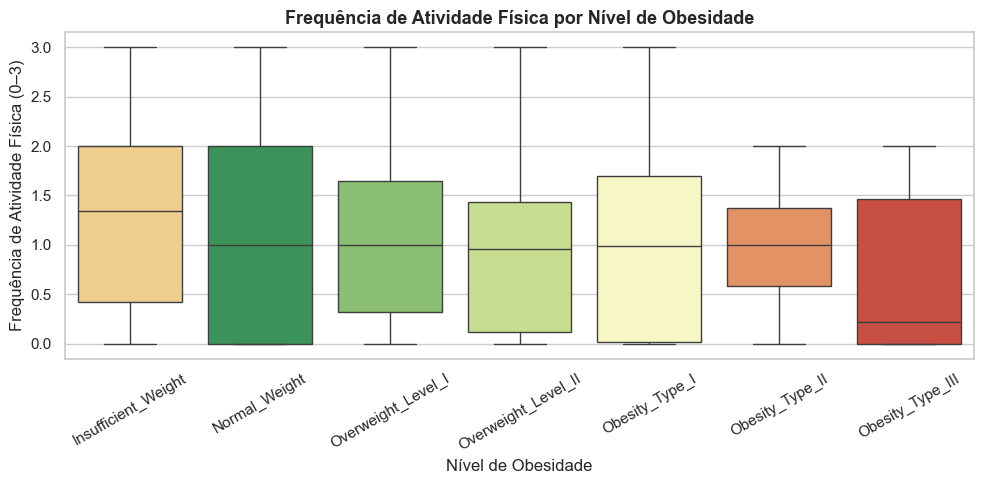

In [19]:
# ── GRÁFICO 4: Atividade física x Obesidade ──────────────────
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='Obesity', y='FAF', order=ordem_obesidade,
            hue='Obesity', palette='RdYlGn_r', legend=False, ax=ax)
ax.set_title('Frequência de Atividade Física por Nível de Obesidade',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nível de Obesidade')
ax.set_ylabel('Frequência de Atividade Física (0–3)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

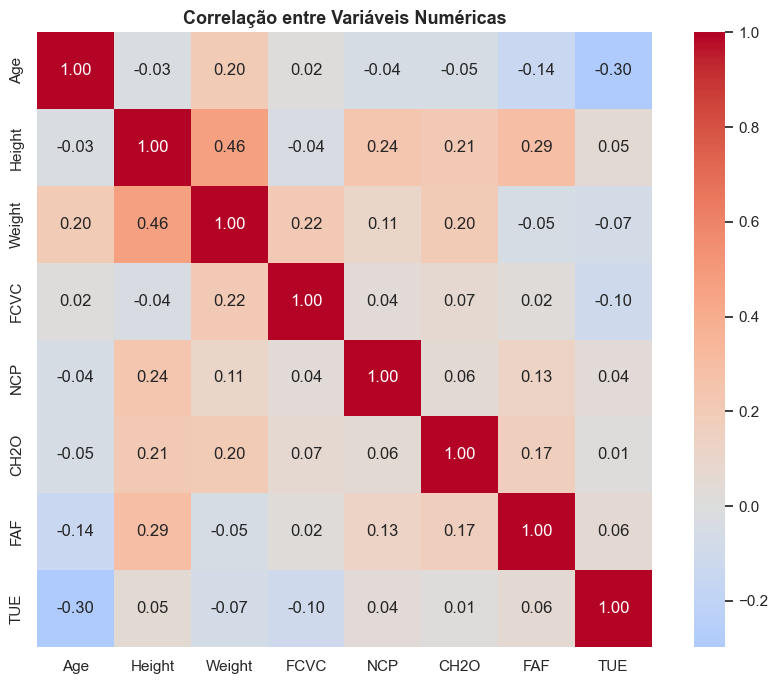

In [20]:
# ── GRÁFICO 5: Correlação entre variáveis numéricas ──────────
# Um heatmap de correlação mostra o quanto duas variáveis
# numéricas "andam juntas".
#   +1 → correlação positiva perfeita (uma sobe, a outra sobe)
#   -1 → correlação negativa perfeita (uma sobe, a outra desce)
#    0 → sem relação
num_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
correlacao = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax)
ax.set_title('Correlação entre Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Fim da análise exploratória

2 - Preparando dados para o modelo

In [21]:
#1. Codificação de Variáveis Categóricas (Encoding)
#Variáveis Binárias (Sim/Não): Colunas como family_history, FAVC, SMOKE e SCC devem ser convertidas diretamente para 1 (Sim) e 0 (Não).  
#Variáveis Categóricas Nominais (Sem ordem): Colunas como Gender e MTRANS (Meio de transporte) devem passar por um processo chamado One-Hot Encoding (gerando colunas do tipo dummy para cada opção, como MTRANS_Public_Transportation, MTRANS_Automobile, etc.). 
#Variáveis Categóricas Ordinais (Com ordem): Colunas como CAEC (Beliscar entre refeições) e CALC (Consumo de álcool) têm uma gradação clara (Não/Às vezes/Frequentemente/Sempre). Elas devem ser mapeadas para uma escala numérica ordenada (0, 1, 2, 3).  
#Variável Alvo (Obesity_level): Como é uma classificação com vários níveis, usaremos o LabelEncoder para transformar os textos dos diagnósticos em classes numéricas (de 0 a 6).  


In [22]:
#2. Normalização / Escalonamento (Scaling): 
# As variáveis numéricas puras têm escalas muito diferentes:
# A idade (Age) varia de 14 a 61.  
# A altura (Height) varia de 1.45 a 1.98.  
# O peso (Weight) varia de 39 a 173.  
# Se jogarmos esses números brutos no modelo, ele pode achar que o Weight é infinitamente mais importante que a Height só porque os números são maiores. Para evitar isso, aplicamos técnicas como o StandardScaler (para deixar a média em 0 e desvio padrão em 1) ou MinMaxScaler (para espremer todos os valores entre 0 e 1).

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
# Para evitar vazamento de dados, dividimos o dataset em treino e teste antes de aplicar qualquer transformação.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder

In [24]:
df.columns = df.columns.str.strip()

In [25]:

# X contém todas as colunas, exceto a variável alvo
X = df.drop(columns=['Obesity'])

# y contém apenas a variável alvo (o diagnóstico)
y = df['Obesity']

In [26]:
#Eu estava tendo um problema com Value Error e para evitar isso fiz uma detecção automática de colunas numéricas e categóricas, ao invés de definir manualmente.

# Coleta todas as colunas numéricas automaticamente
colunas_numericas = X.select_dtypes(include=[np.number]).columns.tolist()

# Coleta as colunas que são textos de Sim/Não (Binárias)
colunas_binarias = [col for col in X.select_dtypes(include=['object']).columns if X[col].nunique() == 2]

# Colunas com ordem explícita segundo o dicionário do hospital
colunas_ordinais = ['CAEC', 'CALC']

# As colunas nominais serão o que sobrar dos textos (ex: MTRANS)
colunas_textuais = X.select_dtypes(include=['object']).columns.tolist()
colunas_nominais = [col for col in colunas_textuais if col not in colunas_binarias and col not in colunas_ordinais]

print("Colunas detectadas e validadas:")
print(f"Numéricas: {colunas_numericas}")
print(f"Binárias: {colunas_binarias}")
print(f"Ordinais: {colunas_ordinais}")
print(f"Nominais (Multi-classe): {colunas_nominais}\n")

Colunas detectadas e validadas:
Numéricas: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
Binárias: ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']
Ordinais: ['CAEC', 'CALC']
Nominais (Multi-classe): ['MTRANS']



C:\Users\BITTAR\AppData\Local\Temp\ipykernel_16576\2281381410.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_binarias = [col for col in X.select_dtypes(include=['object']).columns if X[col].nunique() == 2]
C:\Users\BITTAR\AppData\Local\Temp\ipykernel_16576\2281381410.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this wa

In [27]:
# Agora vamos construir um pipeline de pré-processamento que aplica as transformações corretas a cada tipo de coluna.
# 2. Definindo a ordem das categorias para o OrdinalEncoder (do menor hábito ao maior)
ordem_categorias = [['no', 'Sometimes', 'Frequently', 'Always'],  # Ordem para CAEC
                    ['no', 'Sometimes', 'Frequently', 'Always']]  # Ordem para CALC

# 3. Construindo o transformador de colunas
precomputador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('nom', OneHotEncoder(handle_unknown='ignore'), colunas_nominais),
        ('bin', OneHotEncoder(drop='if_binary'), colunas_binarias),
        ('ord', OrdinalEncoder(categories=ordem_categorias), colunas_ordinais)
    ]
)

In [28]:

from sklearn.preprocessing import LabelEncoder

mapeador_alvo = LabelEncoder()
y_transformado = mapeador_alvo.fit_transform(y)

# ver quem virou o que
for código, classe in enumerate(mapeador_alvo.classes_):
    print(f"Classe {código} -> {classe}")

Classe 0 -> Insufficient_Weight
Classe 1 -> Normal_Weight
Classe 2 -> Obesity_Type_I
Classe 3 -> Obesity_Type_II
Classe 4 -> Obesity_Type_III
Classe 5 -> Overweight_Level_I
Classe 6 -> Overweight_Level_II


In [29]:
# Agora vamos dividir o dataset em treino e teste, garantindo que a proporção de cada classe seja mantida (stratify).
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformado, test_size=0.2, random_state=42, stratify=y_transformado
)

print(f"Pacientes para treino: {X_train.shape[0]}")
print(f"Pacientes para teste: {X_test.shape[0]}")

Pacientes para treino: 1688
Pacientes para teste: 423


In [30]:
X_train_proc = precomputador.fit_transform(X_train)
X_test_proc = precomputador.transform(X_test)

Dados Processados e prontos para o modelo

Modelo

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score

In [32]:
# Treinando os modelos de Machine Learning
# Modelo A: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_proc, y_train)
rf_preds = rf_model.predict(X_test_proc)

# Modelo B: Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train_proc, y_train)
gb_preds = gb_model.predict(X_test_proc)

In [33]:
# Avaliando os modelos
rf_acc = accuracy_score(y_test, rf_preds) * 100
gb_acc = accuracy_score(y_test, gb_preds) * 100

In [34]:
print("PERFORMANCE DOS MODELOS RELEVANTE PARA O HOSPITAL")
print(f"Random Forest:       {rf_acc:.2f}% de acurácia")
print(f"Gradient Boosting:   {gb_acc:.2f}% de acurácia")

PERFORMANCE DOS MODELOS RELEVANTE PARA O HOSPITAL
Random Forest:       95.04% de acurácia
Gradient Boosting:   94.80% de acurácia


In [35]:
#Salvando o modelo
import joblib

In [36]:
# Salva o modelo vencedor (Random Forest)
joblib.dump(rf_model, 'modelo_obesidade.pkl')

['modelo_obesidade.pkl']

In [37]:
# Salva o precomputador (para tratar os dados que o médico digitar no app da mesma forma)
joblib.dump(precomputador, 'precomputador_obesidade.pkl')

['precomputador_obesidade.pkl']

In [38]:
# Salva o mapeador do alvo (para converter o número da previsão de volta para o texto do diagnóstico)
joblib.dump(mapeador_alvo, 'mapeador_alvo_obesidade.pkl')

['mapeador_alvo_obesidade.pkl']

Fim do modelo